In [1]:

import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *
# sys.path = original_sys_path

In [27]:
max_ql = 25
max_ol = 40
system = fluxonium_oscillator_system(
    EJ = 2.5,
    EC = 0.65,
    EL = 0.12,
    Er = 7.05877808,
    g_strength = 0.2,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.001,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2',
    w_d = 7.0585
    )

# 15=> 1e-6
t_rise = 40


square_t_stop = 594.3
area_under_square  = square_t_stop
area_under_rise_and_fall = t_rise
t_stop = 2 * t_rise + (square_t_stop-area_under_rise_and_fall)

tot_time = int(t_stop + 20)

tot_time = 43
tlist = np.linspace(0, tot_time, tot_time)

results = system.run_mesolve_on_driving_osc(
    initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i, 0)])) for i in range(4)],
    tlist = tlist,
    osc_decay = False,
    amp = 0.0015,
    t_stop = t_stop,
    t_rise = t_rise
)


 Total run time: 244.65s*] Elapsed 244.65s / Remaining 00:00:00:04


Processing states with pad_back_custom: 100%|██████████| 43/43 [00:00<00:00, 125.89it/s]


 Total run time: 312.44s*] Elapsed 312.44s / Remaining 00:00:00:06


Processing states with pad_back_custom: 100%|██████████| 43/43 [00:00<00:00, 126.01it/s]


 Total run time: 332.45s*] Elapsed 332.45s / Remaining 00:00:00:06


Processing states with pad_back_custom: 100%|██████████| 43/43 [00:00<00:00, 128.05it/s]


 Total run time: 333.27s*] Elapsed 333.27s / Remaining 00:00:00:06


Processing states with pad_back_custom: 100%|██████████| 43/43 [00:00<00:00, 129.06it/s]


In [25]:
# with open('../pickles/sesolve_three_outcome_large_dim_smooth_edges.pkl', 'wb') as file:
#     pickle.dump(results,file)

In [29]:
with open('../pickles/sesolve_three_outcome_large_dim_smooth_edges.pkl', 'rb') as file:
    results = pickle.load(file)

In [ ]:
lists = []
for ql in [0,1,2,3]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 0
        for q in range(system.qbt.truncated_dim):
            if q != ql:
                for o in range(system.osc.truncated_dim):
                    product_state = (q, o)
                    dressed_state = system.product_to_dressed[product_state]
                    basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum += expectation_value

        pop_list.append(pop_sum)
    # print(pop_list)
    lists.append(pop_list)

# with open('../pickles/sesolve_three_outcome_large_dim_smooth_edges_leakage_list.pkl', 'wb') as file:
#     pickle.dump(lists, file)
    

t loop: 100%|██████████| 43/43 [00:05<00:00,  8.18it/s]


Text(0.5, 0, 't (ns)')

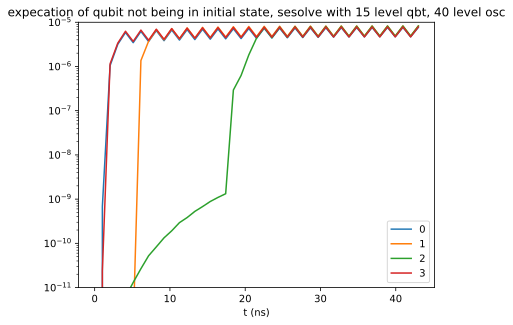

In [28]:
# with open('../pickles/sesolve_three_outcome_large_dim_smooth_edges_leakage_list.pkl', 'rb') as file:
#     lists = pickle.load(file)
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.ylim(1e-11,1e-5)
plt.legend()
plt.title('expecation of qubit not being in initial state, sesolve with 15 level qbt, 40 level osc')
plt.xlabel('t (ns)')

In [31]:
interactive_heatmap(results[3], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=628), Output(…